# Libraries and Data

In [126]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings('ignore')

In [127]:
df = pd.read_csv("airmiles.csv", index_col="Date", parse_dates=True, dayfirst=True)
df.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [128]:
# Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 113 entries, 1996-01-01 to 2005-05-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   airmiles  113 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [129]:
# Setting the Frequency
df = df.asfreq("D")

In [130]:
df = df.asfreq('MS')

In [131]:
df.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq='MS')

# Exploratory Data Analysis

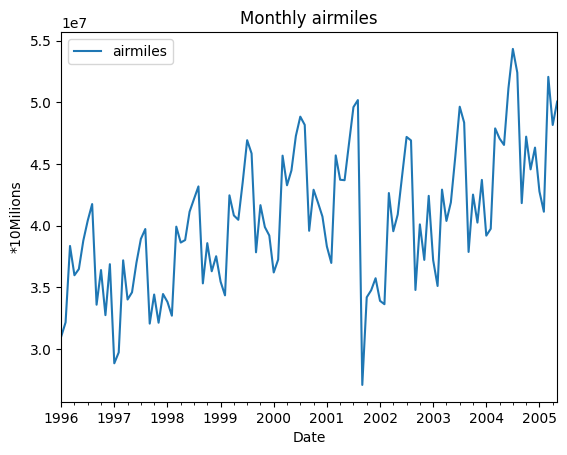

In [132]:
# Daily Closing Price  Plot
df.plot(title = 'Monthly airmiles')
plt.ylabel('*10Milions')
plt.show()

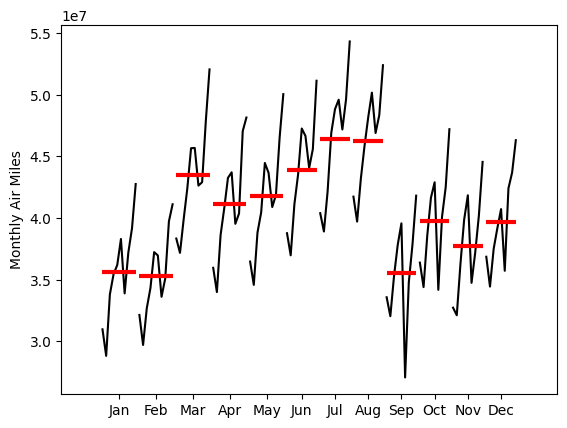

In [133]:
# Plotting the monthly seasonality
month_plot(df['airmiles'],
           ylabel='Monthly Air Miles'
          )
plt.show()

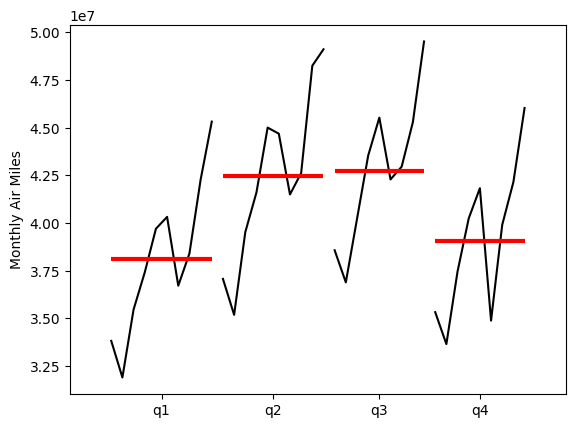

In [134]:
# Plotting the Quarter seasonality
quarter_plot(df['airmiles'].resample('QE').mean(),
           ylabel='Monthly Air Miles'
          )
plt.show()

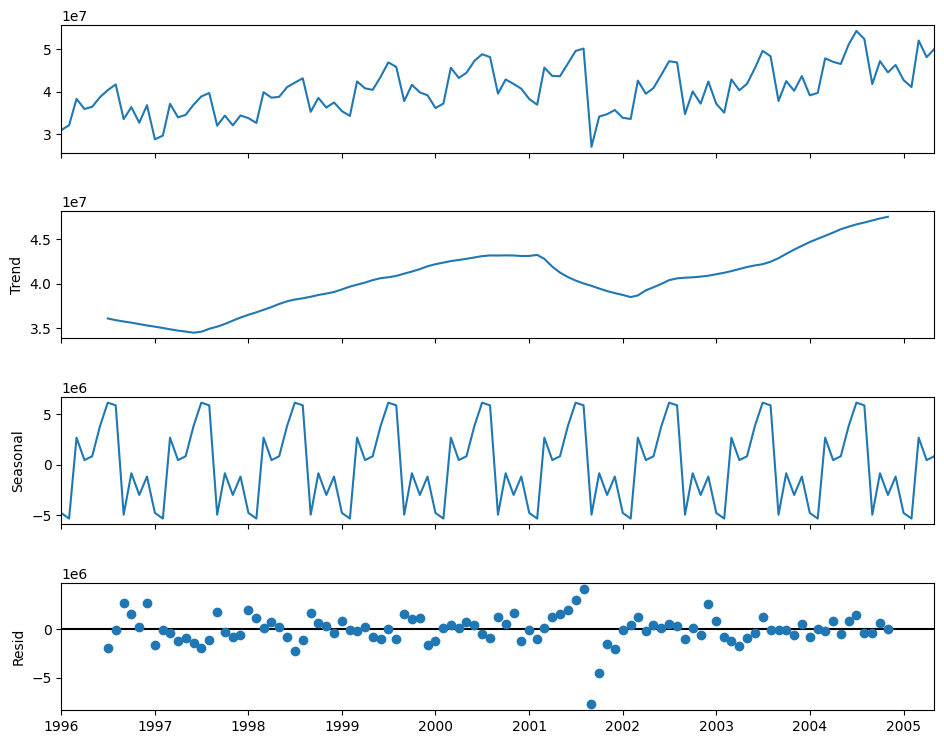

In [135]:
# Seasonal Decomposition Plots for Airmiles Data
decomposition = seasonal_decompose(df,
                                   model = 'add',
                                   period = 12)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

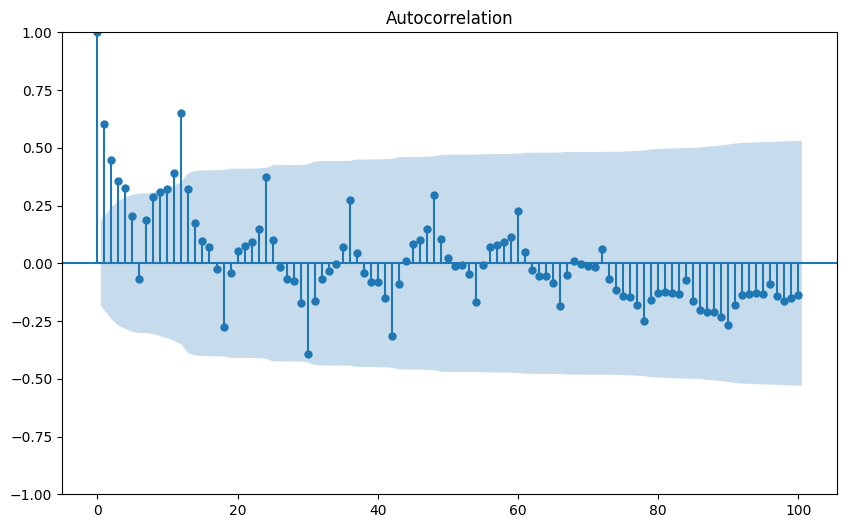

In [136]:
# Plot the autocorrelation (ACF)
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df, lags = 100, ax = ax)
plt.show()

# Train , Test Split

In [137]:
# Training and Test Split
periods = 12
train, test = df.iloc[:-12,0], df.iloc[-12:,0]

In [138]:
train

Date
1996-01-01    30983174.0
1996-02-01    32147663.0
1996-03-01    38342975.0
1996-04-01    35969113.0
1996-05-01    36474391.0
                 ...    
2004-01-01    39180114.0
2004-02-01    39736435.0
2004-03-01    47876012.0
2004-04-01    47050439.0
2004-05-01    46534130.0
Freq: MS, Name: airmiles, Length: 101, dtype: float64

In [139]:
test

Date
2004-06-01    51134050.0
2004-07-01    54317314.0
2004-08-01    52392985.0
2004-09-01    41816777.0
2004-10-01    47205665.0
2004-11-01    44553653.0
2004-12-01    46316602.0
2005-01-01    42760657.0
2005-02-01    41120838.0
2005-03-01    52053059.0
2005-04-01    48152585.0
2005-05-01    50047901.0
Freq: MS, Name: airmiles, dtype: float64

# Set the model

In [140]:
# Triple Exponential Smoothing Model and Predictions
model = ExponentialSmoothing(train, trend = "add", seasonal='mul', seasonal_periods=12).fit()
prediction = model.forecast(len(test))
prediction

2004-06-01    4.985031e+07
2004-07-01    5.224279e+07
2004-08-01    5.236168e+07
2004-09-01    4.136596e+07
2004-10-01    4.618046e+07
2004-11-01    4.350886e+07
2004-12-01    4.564370e+07
2005-01-01    4.123315e+07
2005-02-01    4.082851e+07
2005-03-01    5.023941e+07
2005-04-01    4.767275e+07
2005-05-01    4.818133e+07
Freq: MS, dtype: float64

# Model Assessment

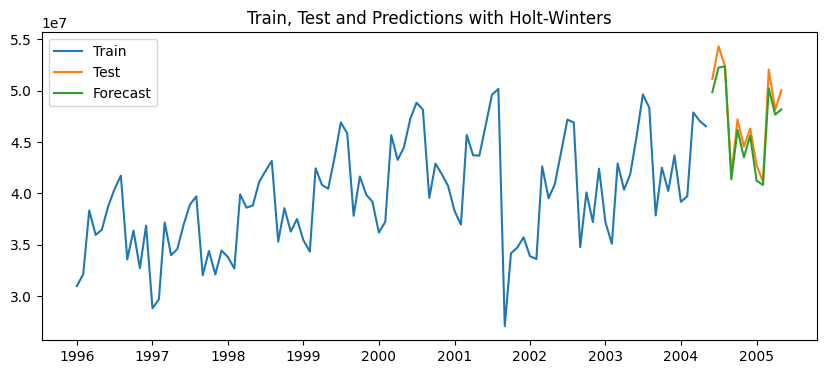

The MAE is 1046933.53
The RMSE is 1230641.26
The MAPE is 2.16 %


In [141]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):
  # Plot training, test, and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = mean_squared_error(test, predictions, squared = False)
  mape = mean_absolute_percentage_error(test, predictions)

  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

model_assessment(train, test, prediction, "Holt-Winters")

# Predicting the future

In [142]:
#Future
model = ExponentialSmoothing(df, trend = "add", seasonal='mul', seasonal_periods=12).fit()
# Prévoir les 6 prochains mois 
nombre_de_mois_a_prevoir = 6
future = model.forecast(steps=nombre_de_mois_a_prevoir)
future

2005-06-01    5.312494e+07
2005-07-01    5.577188e+07
2005-08-01    5.548414e+07
2005-09-01    4.362999e+07
2005-10-01    4.907124e+07
2005-11-01    4.638544e+07
Freq: MS, dtype: float64

In [143]:
# Function to plot the future
def plot_future(y, forecast, title):
  # Plot training and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

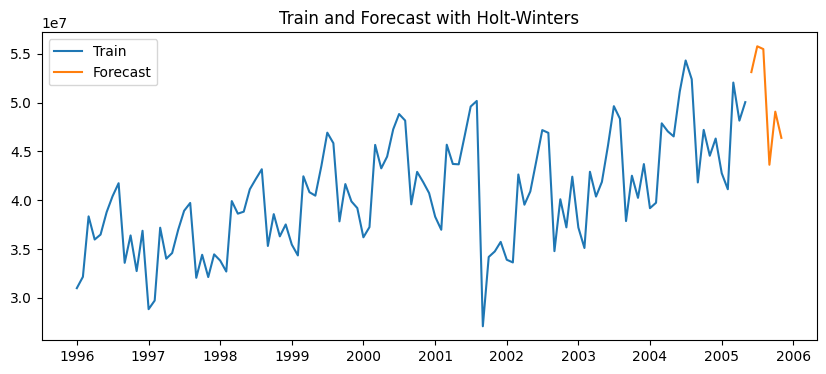

In [144]:
future_airmiles = plot_future(df, future, "Holt-Winters")